In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from imblearn.under_sampling import RandomUnderSampler

c:\Users\ejeme\Documents\python_repos\selective-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset : https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=BNG%28SPECTF%29&id=1212

In [2]:
# Load ARFF file
data, meta = arff.loadarff('C:/Users/ejeme/Documents/BNG_SPECTF.arff')

# Convert to Pandas DataFrame
df = pd.DataFrame(data)

# If the class label is a byte string (common in ARFFs), decode it
if df.select_dtypes([object]).shape[1] > 0:
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')

df = df.astype(float)

# Show the data
display(df.head())

,OVERALL_DIAGNOSIS,F1R,F1S,F2R,F2S,F3R,F3S,F4R,F4S,F5R,...,F18R,F18S,F19R,F19S,F20R,F20S,F21R,F21S,F22R,F22S
0,0.0,72.789368,43.197364,64.704508,70.362702,69.622136,61.617030,73.983803,78.309827,67.969042,...,68.192782,68.005343,55.276038,70.076411,72.014599,71.422812,43.530015,66.880526,55.343422,59.693845
1,0.0,78.354934,73.918344,64.448293,74.108565,77.479515,64.879952,76.673809,76.437381,69.161860,...,62.243551,69.754513,64.590139,75.372622,66.023776,44.293267,72.940177,69.090365,64.461789,61.653021
2,1.0,74.126554,74.902650,51.913819,73.736650,54.796052,60.125431,48.215914,67.367521,37.120961,...,68.948387,65.364597,75.557175,39.191329,65.576923,72.755410,63.611130,62.257647,52.737412,45.866154
3,1.0,63.622860,61.957753,65.722522,79.140667,63.035662,59.939598,57.022926,75.580615,78.487474,...,66.322097,68.430285,71.603408,61.769174,64.331079,73.545137,75.641991,75.720928,64.721315,63.659984
4,0.0,55.598185,61.396416,69.197028,73.145230,51.803761,67.198248,62.893960,70.310560,71.702412,...,63.171356,62.901890,76.313010,70.375106,70.195301,57.105760,77.247967,65.102547,66.374004,69.299237


In [3]:
df.shape

(1000000, 45)

In [4]:
print('Proportion of 1s:', np.round(df.OVERALL_DIAGNOSIS.sum()/df.shape[0],2))

Proportion of 1s: 0.72


#### some preprocessing

In [5]:
features = df.drop(['OVERALL_DIAGNOSIS'], axis=1)
# missing values mean imputation
features = features.fillna(features.mean(numeric_only=True))
features.head()

,F1R,F1S,F2R,F2S,F3R,F3S,F4R,F4S,F5R,F5S,...,F18R,F18S,F19R,F19S,F20R,F20S,F21R,F21S,F22R,F22S
0,72.789368,43.197364,64.704508,70.362702,69.622136,61.617030,73.983803,78.309827,67.969042,38.197976,...,68.192782,68.005343,55.276038,70.076411,72.014599,71.422812,43.530015,66.880526,55.343422,59.693845
1,78.354934,73.918344,64.448293,74.108565,77.479515,64.879952,76.673809,76.437381,69.161860,70.447417,...,62.243551,69.754513,64.590139,75.372622,66.023776,44.293267,72.940177,69.090365,64.461789,61.653021
2,74.126554,74.902650,51.913819,73.736650,54.796052,60.125431,48.215914,67.367521,37.120961,66.212092,...,68.948387,65.364597,75.557175,39.191329,65.576923,72.755410,63.611130,62.257647,52.737412,45.866154
3,63.622860,61.957753,65.722522,79.140667,63.035662,59.939598,57.022926,75.580615,78.487474,59.478458,...,66.322097,68.430285,71.603408,61.769174,64.331079,73.545137,75.641991,75.720928,64.721315,63.659984
4,55.598185,61.396416,69.197028,73.145230,51.803761,67.198248,62.893960,70.310560,71.702412,63.703366,...,63.171356,62.901890,76.313010,70.375106,70.195301,57.105760,77.247967,65.102547,66.374004,69.299237


In [6]:
X = features
Y = df.OVERALL_DIAGNOSIS

In [7]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [10]:
model = LogisticRegression(random_state=0, max_iter=10000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [11]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.18      0.27    168780
         1.0       0.74      0.93      0.83    431220

    accuracy                           0.72    600000
   macro avg       0.63      0.56      0.55    600000
weighted avg       0.68      0.72      0.67    600000

Test Accuracy: 0.72136


### Retrieving $\kappa_f$ confidence function

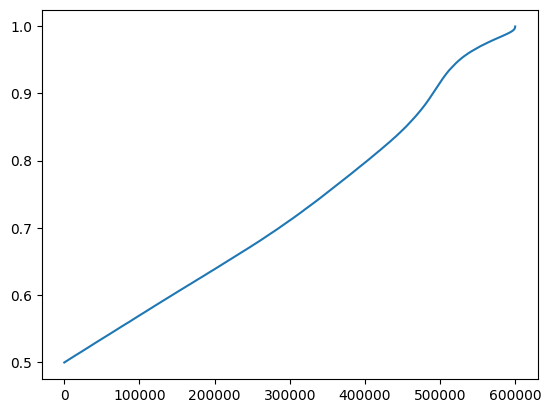

In [12]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [13]:
sgr_df = pd.DataFrame({'y_true': y_true,
              'y_pred': y_pred,
              'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
909024,1.0,1.0,0.500001
814363,0.0,1.0,0.500001
154314,0.0,0.0,0.500002
846639,1.0,0.0,0.500003
389456,1.0,0.0,0.500004
...,...,...,...
499705,1.0,1.0,0.999080
698340,1.0,1.0,0.999149
584104,1.0,1.0,0.999178
64576,1.0,1.0,0.999230


In [14]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> MLP

In [23]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Define  small MLP 
class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super(SmallMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
input_dim = X_train_tensor.shape[1]
model = SmallMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: Evaluate on test set
    if epoch % 10 == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_preds_binary = (test_preds > 0.5).float()
            test_acc = (test_preds_binary == Y_test_tensor).float().mean().item()
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch 0 | Loss: 0.7322 | Test Acc: 42.73%
Epoch 10 | Loss: 0.6009 | Test Acc: 68.59%
Epoch 20 | Loss: 0.5533 | Test Acc: 71.93%
Epoch 30 | Loss: 0.5416 | Test Acc: 71.83%
Epoch 40 | Loss: 0.5363 | Test Acc: 71.77%
Epoch 50 | Loss: 0.5306 | Test Acc: 72.10%
Epoch 60 | Loss: 0.5262 | Test Acc: 72.31%
Epoch 70 | Loss: 0.5220 | Test Acc: 72.53%
Epoch 80 | Loss: 0.5183 | Test Acc: 72.74%
Epoch 90 | Loss: 0.5153 | Test Acc: 72.91%
Epoch 99 | Loss: 0.5132 | Test Acc: 73.05%


In [24]:
import pandas as pd
from sklearn.utils import resample

# Combine and balance the test set
df_test = pd.DataFrame(X_test_scaled)
df_test['label'] = Y_test.values

df_balanced = df_test.groupby('label', group_keys=False).apply(
    lambda x: x.sample(df_test['label'].value_counts().min(), random_state=42)
).sample(frac=1, random_state=42)

# Convert to tensors
Xb = torch.tensor(df_balanced.drop('label', axis=1).values, dtype=torch.float32)
Yb = torch.tensor(df_balanced['label'].values, dtype=torch.float32).view(-1, 1)

# Evaluate on balanced test set
model.eval()
with torch.no_grad():
    pred_probs = model(Xb)
    pred_labels = (pred_probs > 0.5).float()
    acc = (pred_labels == Yb).float().mean().item()
    print(f"Balanced Test Accuracy: {acc*100:.2f}%")


Balanced Test Accuracy: 57.11%


C:\Users\ejeme\AppData\Local\Temp\ipykernel_6192\3889851084.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_test.groupby('label', group_keys=False).apply(


In [14]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor)  # Shape: (num_samples, 1)
    test_preds = (test_probs > 0.5).float() 

In [17]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': test_preds.numpy().astype(int).flatten(),
                       'kappa': test_probs.numpy().flatten()}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
808210,0.0,0,0.155454
880478,0.0,0,0.178161
764341,0.0,0,0.181641
64363,0.0,0,0.191834
947396,0.0,0,0.192952
...,...,...,...
924458,1.0,1,0.999431
64576,1.0,1,0.999441
584104,1.0,1,0.999490
752850,1.0,1,0.999502


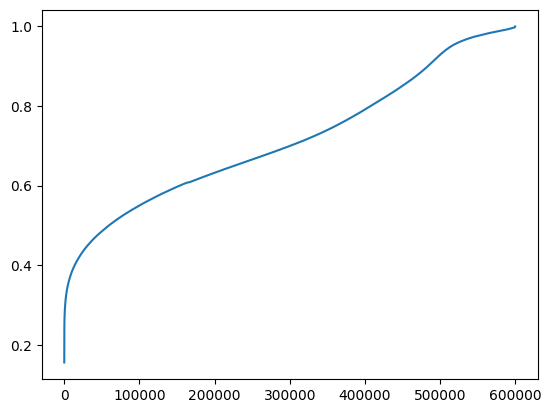

In [18]:
plt.plot(sorted(sgr_df.kappa))
plt.show()

In [19]:
pickle.dump(sgr_df, open('sgr_set_mlp', 'wb'))